# Model

In [4]:
import pandas as pd
import numpy as np

In [5]:
# Make a copy so you don't overwrite your original dataset
df_queue = pd.read_csv("Datasets\GI_Interactive_Queue.csv")
df = df_queue.copy()

# --------------------------------------------------
# 1. CLEAN VARIABLES
# --------------------------------------------------

df["Queue Date"] = pd.to_datetime(
    df["Queue Date"],
    errors="coerce"
)

df["Summer MW"] = pd.to_numeric(
    df["Summer MW"],
    errors="coerce"
)

# Project age in years
today = pd.Timestamp.today(tz="UTC")

df["Age Years"] = (
    (today - df["Queue Date"]).dt.days / 365.25
)

<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
C:\Users\moaxs\AppData\Local\Temp\ipykernel_8184\1946695964.py:2: SyntaxWarning: invalid escape sequence '\G'
  df_queue = pd.read_csv("Datasets\GI_Interactive_Queue.csv")


## Size Risk

Normalize size of projects to estimate their impact on grid

In [6]:
def normalize_01(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(0, index=series.index)

    return (series - minimum) / (maximum - minimum)

In [7]:
df["Size Risk"] = normalize_01(
    np.log1p(df["Summer MW"])
)

## Fuel Type Risk

These coefficients are example assumptions

In [8]:
fuel_risk = {
    "Battery Storage": 0.20,
    "Gas": 0.30,
    "Combined Cycle": 0.30,
    "Nuclear": 0.35,
    "Hydro": 0.35,

    "Hybrid": 0.40,

    "Solar": 0.60,
    "Wind": 0.60,

    "Biomass": 0.50,
    "Diesel": 0.50,
    "Waste Heat Recovery": 0.50,
    "Compressed Air Storage": 0.40,
    "High Voltage DC": 0.50,
    "Coal": 0.50
}

df["Fuel Risk"] = (
    df["Fuel"]
    .map(fuel_risk)
    .fillna(0.50)
)

## Service Type Risk

NRIS is more demanding resource to provide. Therefore the coefficient will be higher, both are also examples.

In [9]:
service_risk = {
    "ERIS": 0.30,
    "NRIS": 0.60
}

df["Service Risk"] = (
    df["Service Type"]
    .map(service_risk)
    .fillna(0.50)
)

## Decision Point Risk

Add the decision point to see how much the facility is wanting to add to grid demand.

In [10]:
df["DP1 NRIS"] = (
    df["Decision Point 1 NRIS MW"]
)

df["Decision Point Risk"] = (
    df["DP1 NRIS"]
    .replace([np.inf, -np.inf], np.nan)
    .clip(0, 1)
    .fillna(0)
)

## Age Factor

Loads that have already been in the queue longer should gain a higher score over time so they are eventually considered.

In [11]:
df["Age Risk"] = normalize_01(
    df["Age Years"]
)

## State Factor

Some states have higher withdraw rates

In [12]:
historical = df[
    df["Request Status"].isin(["Done", "Withdrawn"])
].copy()

historical["Withdrawn Flag"] = (
    historical["Request Status"] == "Withdrawn"
).astype(int)

In [13]:
state_risk = (
    historical
    .groupby("State")["Withdrawn Flag"]
    .mean()
)

df["State Risk"] = (
    df["State"]
    .map(state_risk)
    .fillna(historical["Withdrawn Flag"].mean())
)

## Transmission Owner Factor

This factor is related to how frequently a transmission owner withdraws their projects.

In [14]:
owner_risk = (
    historical
    .groupby("Transmission Owner")["Withdrawn Flag"]
    .mean()
)

df["Transmission Owner Risk"] = (
    df["Transmission Owner"]
    .map(owner_risk)
    .fillna(historical["Withdrawn Flag"].mean())
)

## Assign Weights to Each Factor

For early models we will assume each factor to have equal weights, this should be adjusted.

In [15]:
weights = {
    "Size Risk": 1/7,
    "Service Risk": 1/7,
    "Fuel Risk": 1/7,
    "Decision Point Risk": 1/7,
    "Transmission Owner Risk": 1/7,
    "State Risk": 1/7,
    "Age Risk": 1/7
}

df["Raw Risk"] = (
    weights["Size Risk"] *
    df["Size Risk"] +

    weights["Service Risk"] *
    df["Service Risk"] +

    weights["Fuel Risk"] *
    df["Fuel Risk"] +

    weights["Decision Point Risk"] *
    df["Decision Point Risk"] +

    weights["Transmission Owner Risk"] *
    df["Transmission Owner Risk"] +

    weights["State Risk"] *
    df["State Risk"] -

    weights["Age Risk"] *
    df["Age Risk"]
)

- Standardize scores from 1-10 with 10 being the lowest risk and highest priority for building quickly

In [16]:
df["Impact Score"] = (
    10 -
    9 * normalize_01(df["Raw Risk"])
)

df["Impact Score"] = (
    df["Impact Score"]
    .round(2)
)

## See Some Results

Print some rows to see what results look like

In [17]:
results = df[
    [
        "Project #",
        "State",
        "Fuel",
        "Summer MW",
        "Age Years",
        "Size Risk",
        "Service Risk",
        "Fuel Risk",
        "Decision Point Risk",
        "State Risk",
        "Transmission Owner Risk",
        "Age Risk",
        "Raw Risk",
        "Impact Score"
    ]
]

print(
    results
    .sort_values(
        "Impact Score",
        ascending=False)
    .head(5)
)

     Project # State             Fuel  Summer MW  Age Years  Size Risk  \
819      J1819    AR  Battery Storage        0.0   6.209446        0.0   
607      J1607    AR  Battery Storage        0.0   6.209446        0.0   
821      J1821    AR  Battery Storage        0.0   6.209446        0.0   
759      J1759    LA  Battery Storage        0.0   6.214921        0.0   
3573     R1014   NaN              NaN        0.0   4.596851        0.0   

      Service Risk  Fuel Risk  Decision Point Risk  State Risk  \
819            0.6        0.2                  0.0    0.830769   
607            0.6        0.2                  0.0    0.830769   
821            0.6        0.2                  0.0    0.830769   
759            0.6        0.2                  0.0    0.831776   
3573           0.5        0.5                  0.0    0.793116   

      Transmission Owner Risk  Age Risk  Raw Risk  Impact Score  
819                       0.0  0.541767  0.155572         10.00  
607                       

In [18]:
summary = results.describe().transpose()
summary

,count,mean,std,min,25%,50%,75%,max
Summer MW,3822.0,181.932729,170.470410,0.000000,100.000000,150.000000,200.000000,2220.000000
Age Years,3816.0,4.468648,2.490643,0.065708,2.398357,3.989049,6.212183,11.405886
Size Risk,3822.0,0.629947,0.135001,0.000000,0.598922,0.651112,0.688230,1.000000
Service Risk,3822.0,0.574673,0.075548,0.300000,0.600000,0.600000,0.600000,0.600000
Fuel Risk,3822.0,0.484759,0.159818,0.200000,0.400000,0.600000,0.600000,0.600000
Decision Point Risk,3822.0,0.384877,0.486630,0.000000,0.000000,0.000000,1.000000,1.000000
State Risk,3822.0,0.798580,0.056801,0.649718,0.762238,0.805405,0.831776,1.000000
Transmission Owner Risk,3822.0,0.748569,0.243692,0.000000,0.739130,0.787234,0.917526,1.000000
Age Risk,3816.0,0.388260,0.219630,0.000000,0.205698,0.345968,0.542009,1.000000
Raw Risk,3816.0,0.461991,0.079744,0.155572,0.407772,0.461343,0.517472,0.666499


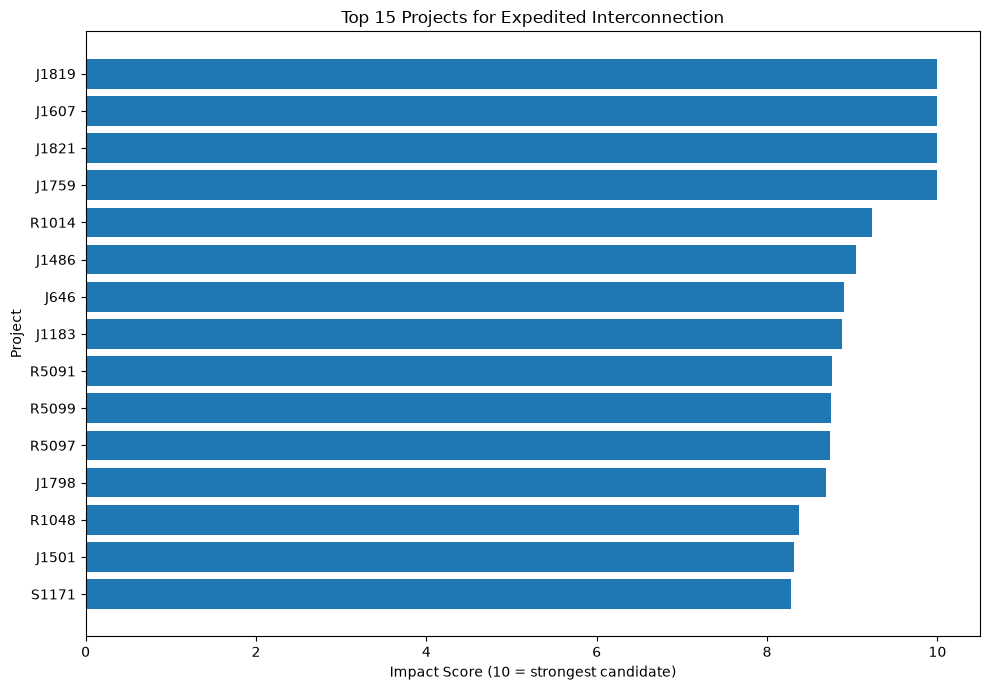

In [19]:
import matplotlib.pyplot as plt

top_projects = (
    df.sort_values("Impact Score", ascending=False)
      .head(15)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_projects["Project #"],
    top_projects["Impact Score"]
)

plt.gca().invert_yaxis()

plt.xlabel("Impact Score (10 = strongest candidate)")
plt.ylabel("Project")
plt.title("Top 15 Projects for Expedited Interconnection")

plt.tight_layout()
plt.show()

## Impact Score by Queue Age
We should pick the projects with highest impact score. These scores generally rise over time to allow older projects to get out of the queue

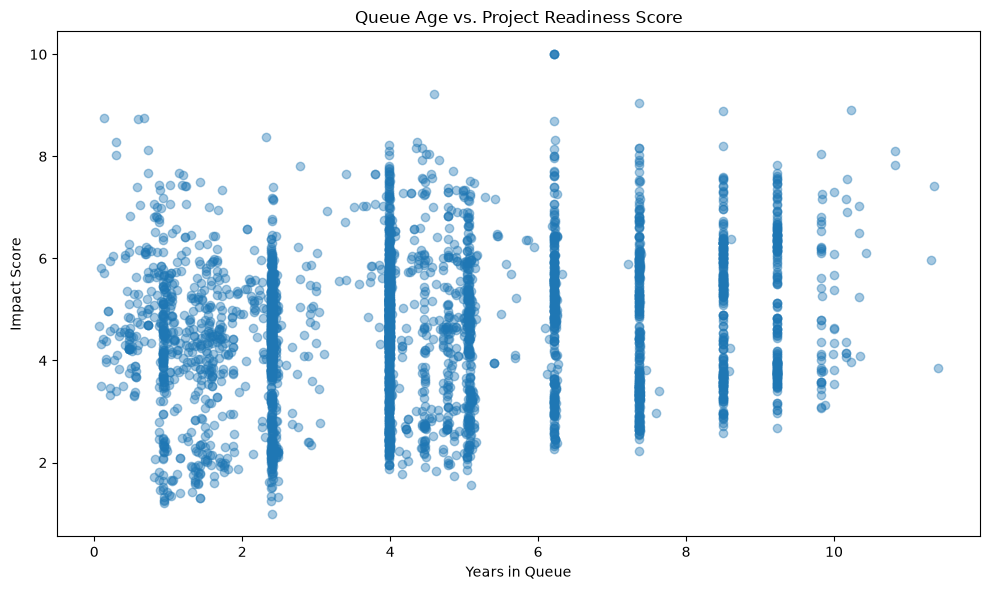

In [20]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Age Years"],
    df["Impact Score"],
    alpha=0.4
)

plt.xlabel("Years in Queue")
plt.ylabel("Impact Score")
plt.title("Queue Age vs. Project Readiness Score")

plt.tight_layout()
plt.show()

## Impact Scores by Fuel Type

Projects with what kind of fuel are most likely to make it through the queue successfully?

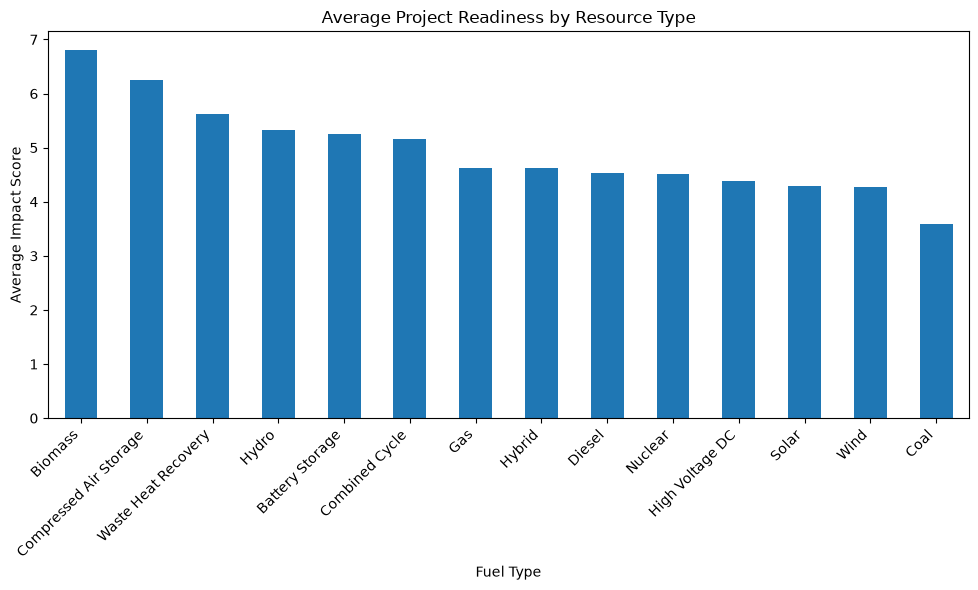

In [21]:
fuel_scores = (
    df.groupby("Fuel")["Impact Score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

fuel_scores.plot(kind="bar")

plt.ylabel("Average Impact Score")
plt.xlabel("Fuel Type")
plt.title("Average Project Readiness by Resource Type")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Impact Score vs Project Size

How are large loads treated by this new queue process? Does the scoring system fairly treat both large and small projects?

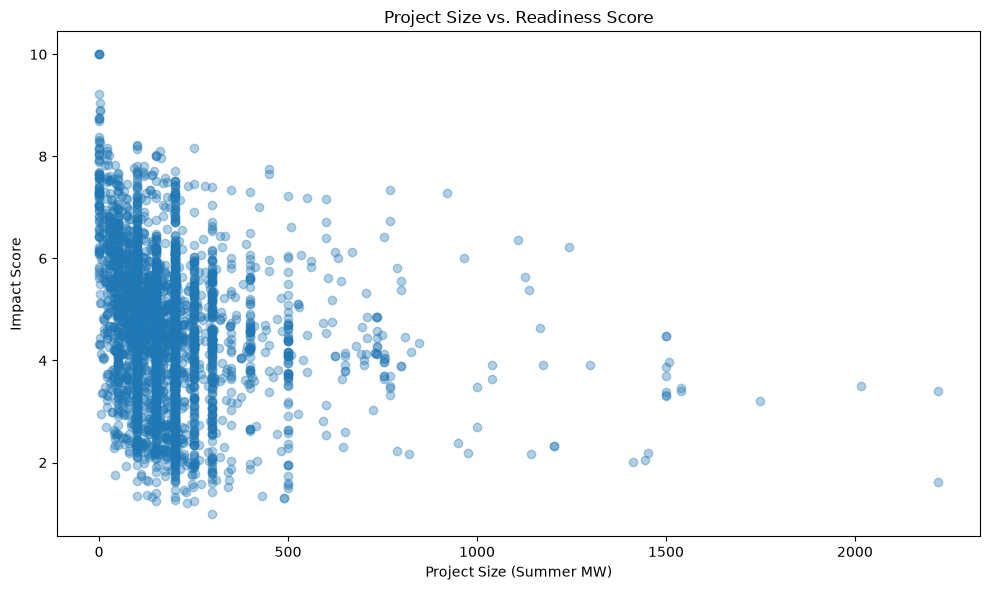

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Summer MW"],
    df["Impact Score"],
    alpha=0.35
)

plt.xlabel("Project Size (Summer MW)")
plt.ylabel("Impact Score")
plt.title("Project Size vs. Readiness Score")

plt.tight_layout()
plt.show()